# <font color='green'>Combining bit-flip and phase-flip repetition codes: Shor's 9-qubit code</font>

So far, we have seen how to encode qubits to protect from bit-flip and phase-flip errors, but only one of these two kinds of errors at a time. The Shor code, Peter Shor in 1995 [1], was the first quantum error-correcting code that could protect against both bit-flip and phase-flip errors. It achieves this through a clever technique called **concatenation** -- essentially nesting one code inside another.

Here, we build the Shor code from scratch, and simulate the logical error probability of the Shor code for various physical error probabilities.

In [1]:
%pip install -e ~/deltakit-textbook
%pip install "mlx[cpu]"

Looking in links: /usr/share/pip-wheels
Obtaining file:///home/f73aeabd-6de4-471d-92a9-1ba552ae6153/deltakit-textbook
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for deltakit-textbook (pyproject.toml) ... done
  Created wheel for deltakit-textbook: filename=deltakit_textbook-0.0.0-0.editable-py3-none-any.whl size=4827 sha256=b4a4554dd4dc1a1c71f13fdc36efd2f26cd0d2ccee3a52ffd0469ac4a1881b27
  Stored in directory: /tmp/pip-ephem-wheel-cache-0vi_0pfe/wheels/5d/bd/f8/449a5f5525755c7915b059424bb229b7b46fd90882998f3811
Successfully built deltakit-textbook
  Attempting uninstall: deltakit-textbook
    Found existing installation: deltakit-textbook 0.0.0
    Uninstalling deltakit-textbook-0.0.0:
      Successfully uninstalled deltakit-textbook-0.0.0
Note: you may need to restart the kernel to use updated packages.

## <font color='blue'>Encoding procedure</font>

The Shor code combines the encoding schemes of both repetition codes that we've seen so far using 9 physical qubits to encode 1 logical qubit.

1. First, encode against bit-flip errors (like the 3-qubit bit-flip code), by encoding $\vert0\rangle \rightarrow \vert000\rangle$ and $\vert1\rangle \rightarrow \vert111\rangle$.
2. Then, encode each qubit within the 3 blocks against phase-flip errors (like in the 3-qubit phase-flip code), by encoding $\vert0\rangle \rightarrow \frac{\vert000\rangle + \vert111\rangle}{\sqrt{2}}$ and $\vert1\rangle \rightarrow \frac{\vert000\rangle - \vert111\rangle}{\sqrt{2}}$ within each block.

This gives us 3 blocks of 3 qubits, for a total of 3 × 3 = 9 physical qubits which will serve as the data qubits.

![img](images/shor-encoding.png)

The logical states are then

$$
\vert0\rangle_L = \left(\frac{\vert000\rangle + \vert111\rangle}{\sqrt{2}}\right)_\text{block 1}\otimes\left(\frac{\vert000\rangle + \vert111\rangle}{\sqrt{2}}\right)_\text{block 2}\otimes\left(\frac{\vert000\rangle + \vert111\rangle}{\sqrt{2}}\right)_\text{block 3}
$$

and

$$
\vert1\rangle_L = \left(\frac{\vert000\rangle - \vert111\rangle}{\sqrt{2}}\right)_\text{block 1}\otimes\left(\frac{\vert000\rangle - \vert111\rangle}{\sqrt{2}}\right)_\text{block 2}\otimes\left(\frac{\vert000\rangle - \vert111\rangle}{\sqrt{2}}\right)_\text{block 3}
$$

and the logical superposition states follow as usual:

$$
\vert+\rangle_L = \frac{\vert0\rangle_L + \vert1\rangle_L}{\sqrt{2}}
$$

and

$$
\vert-\rangle_L = \frac{\vert0\rangle_L - \vert1\rangle_L}{\sqrt{2}}
$$

In [2]:
import numpy as np, random
import matplotlib.pyplot as plt
import cirq
from math import comb, ceil, floor
from myMWPM import MWPMDecoder1D
from tqdm import tqdm
import qec 

In [3]:
encoder = qec.utils.create_shor_encoder(3)
print(encoder)

0: ───@───@───H───@───@───
      │   │       │   │
1: ───┼───┼───────X───┼───
      │   │           │
2: ───┼───┼───────────X───
      │   │
3: ───X───┼───H───@───@───
          │       │   │
4: ───────┼───────X───┼───
          │           │
5: ───────┼───────────X───
          │
6: ───────X───H───@───@───
                  │   │
7: ───────────────X───┼───
                      │
8: ───────────────────X───


## <font color='blue'>Extracting syndromes</font>

As before, we will use syndrome qubits to extract syndromes. Since there are 9 data qubits, we will need to do 8 pairwise parity checks and therefore require 8 additional syndrome qubits, for a total of 17 physical qubits. These 8 pairwise parity checks are composed of two kinds: 6 within-block parity checks to ensure consistency within each block, and 2 block-pair-wise parity checks to ensure consistency across the 3 blocks.

### <font color='red'>Parity checks within blocks</font>

Within each block, we will run $Z_iZ_{i+1}$ parity checks to ensure bitwise consistency within that block, similar to bit-flip repetition codes. Since there are 3 blocks in total, each of which will need 2 such parity checks, we will need a total of 6 syndrome qubits to do this work.

In [4]:
bitflip_syndrome_meas = qec.syndrome_extraction.get_shor_bitflip_syndrome_measurement(3)
print(bitflip_syndrome_meas)

0: ────@───────────────I───────────────────I───────────────────I───────────────────────
       │
1: ────┼───@───@───────I───────────────────I───────────────────I───────────────────────
       │   │   │
2: ────┼───┼───┼───@───I───────────────────I───────────────────I───────────────────────
       │   │   │   │
3: ────┼───┼───┼───┼───I───@───────────────I───────────────────I───────────────────────
       │   │   │   │       │
4: ────┼───┼───┼───┼───I───┼───@───@───────I───────────────────I───────────────────────
       │   │   │   │       │   │   │
5: ────┼───┼───┼───┼───I───┼───┼───┼───@───I───────────────────I───────────────────────
       │   │   │   │       │   │   │   │
6: ────┼───┼───┼───┼───I───┼───┼───┼───┼───I───@───────────────I───────────────────────
       │   │   │   │       │   │   │   │       │
7: ────┼───┼───┼───┼───I───┼───┼───┼───┼───I───┼───@───@───────I───────────────────────
       │   │   │   │       │   │   │   │       │   │   │
8: ────┼───┼───┼───┼───I───┼───┼───┼

### <font color='red'>Parity checks across blocks</font>

We will also run parity checks to ensure _phase_ consistency across all 3 blocks. To do so, we run $X_iX_{i+1}$ parity checks across blocks. Note that when $Z$ errors occur within each block, only an odd number of such errors causes a phase consistency across blocks (since $Z_i\vert111\rangle = -\vert111\rangle$ and $-Z_j\vert111\rangle = \vert111\rangle$ for any $i$ and $j$ within a block). One parity check will measure the phase consistency between blocks 0 and 1 (by running $X_0X_1X_2X_3X_4X_5$), and another will measure the phase consistency between blocks 0 and 2 (by running $X_0X_1X_2X_6X_7X_8$). If two blocks are inconsistent but we know that they are, we can simply apply a single $Z$ gate in one of the blocks to bring them back to consistency and avoid a logical error.

Note that there are two methods for running an $X_iX_j$ parity check (see [Dan Browne's lecture notes, section 1.3.9](https://sites.google.com/site/danbrowneucl/teaching/lectures-on-topological-codes-and-quantum-computation). In one method, we initialize the syndrome qubits in the Hadamard basis, run controlled-$X$ gates from the syndrome qubits to the data qubits, and then measure the syndrome in the Hadamard basis. The circuit identity $HZH = X$ can be used to transform this method into the second: apply $H$ gates to all data qubits, and run controlled-$X$ gates from the data qubits to the syndrome qubits.

We will use the latter method below.

In [5]:
phaseflip_syndrome_meas = qec.syndrome_extraction.get_shor_phaseflip_syndrome_measurement(block_size = 3)
print(phaseflip_syndrome_meas)

               ┌──┐   ┌──┐
0: ────H───@────@────────────────────────────────────────────────────H─────────────────────────
           │    │
1: ────H───┼────┼@─────@─────────────────────────────────────────────H─────────────────────────
           │    ││     │
2: ────H───┼────┼┼─────┼@────@───────────────────────────────────────H─────────────────────────
           │    ││     ││    │
3: ────H───┼────┼┼─────┼┼────┼───────@───────────────────────────────H─────────────────────────
           │    ││     ││    │       │
4: ────H───┼────┼┼─────┼┼────┼───────┼───@───────────────────────────H─────────────────────────
           │    ││     ││    │       │   │
5: ────H───┼────┼┼─────┼┼────┼───────┼───┼───@───────────────────────H─────────────────────────
           │    ││     ││    │       │   │   │
6: ────H───┼────┼┼─────┼┼────┼───────┼───┼───┼───────@───────────────H─────────────────────────
           │    ││     ││    │       │   │   │       │
7: ────H───┼────┼┼─────┼┼────┼───────┼───┼─

## <font color='blue'>Creating the initial state</font>

We will use standard rotations to initialize the state of the qubit that is protected by the Shor code. An $X$ gate will flip it from $\vert0\rangle$ to $\vert1\rangle$, an $H$ gate will flip $\vert0\rangle$ to $\vert+\rangle$, and a combination of both will flip $\vert0\rangle$ to $\vert-\rangle$ ($\vert-\rangle = ZH\vert0\rangle$).

In [6]:
qec.utils.create_initial_state('+')

0: ───H───

## <font color='blue'>Applying noise</font>

As we have seen in the previous chapter on phase-flip repetition codes, we will need to track the errors that we have applied in order to run simulations of the performance of the error-correcting code. The function below applies noise to the relevant data qubits, and then reports which ones it applied.

## <font color='blue'>Putting it all together</font>

We can now combine all the pieces above into a full run of the Shor code. Once we construct the circuit to encode the state of one qubit into the 9 qubits of the Shor code, apply noise, and run our syndrome checks, we will need to decode the syndrome checks and determine whether a logical error has occurred.

A logical error can happen in two ways:
- If a single $Z$ errors happens within a block, then we will be able to determine the location of that block through the phase consistency checks described above. However, if two $Z$ errors happen in two different blocks, then our phase consistency's majority vote will fail to identify where these errors occurred, leading to a logical error.
- If a single $X$ error occurs within a block, then we will be able to determine its location through the within-block bitwise parity checks described above. However, if two $X$ errors occur within the same block, these within-block parity checks will not be able to identify the correct location since the majority vote within the block fails to identify the flipped data qubit and a logical error occurs.

In [7]:
p = 0.1
block_sizes = [3]
simulator = cirq.CliffordSimulator()
physical_errors = np.logspace(-5, 0, 10)  # 10^-5 to 10^0 in 10 logsteps

As before, we write a loop to go through several values of physical error probabilities and test the performance of the error-correcting code to those errors.

In [8]:
# Use n_shots = 10_000_000 for more precise estimates and smaller
# statistical fluctuations, at the cost of longer computation time.
n_shots = 1000  # Quick test; results may have large statistical fluctuations.

all_logical_errors = qec.logical_error.get_logical_error_probability_simulated( [3], physical_errors, 1000, simulator, '0', cirq.Z)

Simulating block-size-3 Shor code circuits


100%|██████████| 10/10 [00:04<00:00,  2.22it/s]


Now, we can derive an analytical expression for the logical error probability using the same arguments that we have previously seen for repetition codes. We will consider the case of $Z$ errors where the initial state is $\vert+\rangle_L$ for simplicity, for the Shor code where the size of each block is $\text{blocksize}$. There are 9 ($\text{blocksize}^2$) data qubits that can experience a $Z$ error. If more than one $Z$ flip occurs, then we will be unable to detect where it happened with our 2 parity checks that compare the blocks.

There are $\binom{9}{0} = 1$ cases where no $Z$ flips occur (with probability $\left(1-p\right)^9$), and $\binom{9}{1} = 9$ cases where one $Z$ flip occurs (with probability $p\left(1-p\right)^8$ each). Any other case leads to a logical error. Then, the probabilty of success is

$$
p_L = 1-p_\text{success} = 1-\binom{\text{blocksize}^2}{0}\left(1-p\right)^9-\binom{\text{blocksize}^2}{1}p\left(1-p\right)^8 = 1 - \left(1-p\right)^9 - 9p\left(1-p\right)^8
$$

This is exactly the same as our previously derived expression

$$
p_L = 1-p_\text{success} =  1-\sum_{n_\text{flips} = 0}^{d/2} \binom{d}{n_\text{flips}}\times p^{n_\text{flips}}\times(1-p)^{d-n_\text{flips}}
$$

where we replace $d$ by $\text{blocksize}^2$ within the sum, since that represents the total number of qubits used in the encoding procedure that could experience errors, but keep the sum running up to at most $\lfloor d/2\rfloor$ since that is the number of flips that will cause a logical error.

In [9]:
all_analytical_errors = qec.logical_error.get_logical_error_probability_analytical(block_sizes, physical_errors)

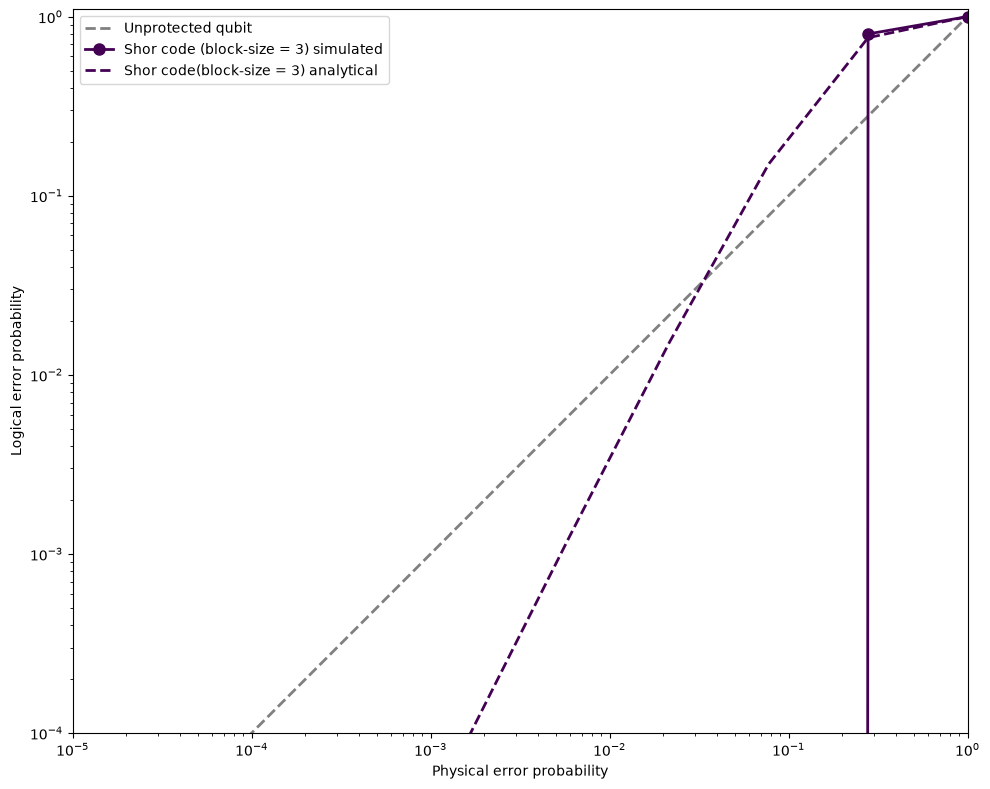

In [10]:
qec.visualization.plot_logical_error_probabilities( block_sizes, physical_errors, all_logical_errors, all_analytical_errors, ylim = [1e-4, 1.1])

## Faster code performance simulations

In order to test the performance of the Shor code at low errors, we will need to run millions of shots. However, the simulation time above is prohibitively high. To get around this problem, we will use the sampling techniques covered in the previous chapter on running faster circuit simulations. We will first adapt the code above to generate a syndrome table that collects all possible error locations and flags to indicate whether or not they lead to a logical error. Then, we will sample from this syndrome table repeatedly instead of running circuits. The code below samples from the syndrome table using the GPU on the author's laptop. If this is not available for you, the speedup from using a syndrome table should still be significant.

In [11]:
try:
    import mlx.core as mx  # Apple's MLX library for Apple Silicon
except ImportError:
    raise RuntimeError("MLX not available")

In [12]:
# Use n_shots = 10_000_000 for more precise estimates and smaller
# statistical fluctuations, at the cost of longer computation time.
n_shots = 50  # Quick test; results may have large statistical fluctuations.

block_sizes = [3]
physical_errors = np.logspace(-5, 0, 10)  # 10^-5 to 10^0 in 10 logsteps

In [13]:
all_logical_errors_0z = qec.logical_error.get_logical_error_probability_simulated_GPU(block_sizes, physical_errors, n_shots, simulator, '0', cirq.Z)

Simulating block-size-3 Shor code circuits
Getting syndromes for all possible error locations in block-size 3, |0>_L, error gate Z


100%|██████████| 512/512 [00:00<00:00, 737.97it/s]
512it [00:00, 5486.39it/s]
100%|██████████| 10/10 [00:00<00:00, 12.59it/s]


In [14]:
all_logical_errors_0x = qec.logical_error.get_logical_error_probability_simulated_GPU(block_sizes, physical_errors, n_shots, simulator, '0', cirq.X)

Simulating block-size-3 Shor code circuits
Getting syndromes for all possible error locations in block-size 3, |0>_L, error gate X


100%|██████████| 512/512 [00:00<00:00, 638.84it/s]
512it [00:00, 95194.10it/s]
100%|██████████| 10/10 [00:00<00:00, 14.27it/s]


In [15]:
all_logical_errors_pz = qec.logical_error.get_logical_error_probability_simulated_GPU(block_sizes, physical_errors, n_shots, simulator, '+', cirq.Z)

Simulating block-size-3 Shor code circuits
Getting syndromes for all possible error locations in block-size 3, |+>_L, error gate Z


100%|██████████| 512/512 [00:00<00:00, 860.21it/s] 
512it [00:00, 120293.73it/s]
100%|██████████| 10/10 [00:00<00:00, 12.55it/s]


In [16]:
all_logical_errors_px = qec.logical_error.get_logical_error_probability_simulated_GPU(block_sizes, physical_errors, n_shots, simulator, '+', cirq.X)

Simulating block-size-3 Shor code circuits
Getting syndromes for all possible error locations in block-size 3, |+>_L, error gate X


100%|██████████| 512/512 [00:01<00:00, 284.30it/s]
512it [00:00, 5241.98it/s]
100%|██████████| 10/10 [00:00<00:00, 11.13it/s]


In [17]:
all_analytical_errors = qec.logical_error.get_logical_error_probability_analytical(block_sizes, physical_errors)

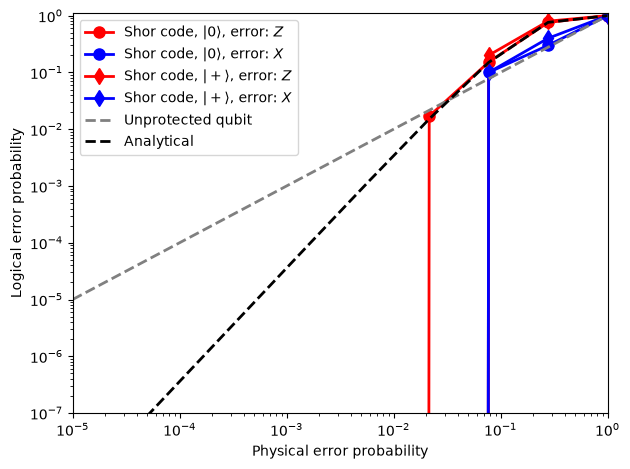

In [18]:
plt.loglog(physical_errors, all_logical_errors_0z[0], label = r'Shor code, $\vert0\rangle$, error: $Z$', marker='o', linewidth=2, markersize=8, color='red')
plt.loglog(physical_errors, all_logical_errors_0x[0], label = r'Shor code, $\vert0\rangle$, error: $X$', marker='o', linewidth=2, markersize=8, color='blue')
plt.loglog(physical_errors, all_logical_errors_pz[0], label = r'Shor code, $\vert+\rangle$, error: $Z$', marker='d', linewidth=2, markersize=8, color='red')
plt.loglog(physical_errors, all_logical_errors_px[0], label = r'Shor code, $\vert+\rangle$, error: $X$', marker='d', linewidth=2, markersize=8, color='blue')
plt.loglog(physical_errors, physical_errors, label = "Unprotected qubit", linestyle='--', linewidth=2, color='gray')
plt.loglog(physical_errors, all_analytical_errors[0], label = "Analytical", linestyle='--', linewidth=2, color='black')
plt.legend()
plt.xlim([physical_errors.min(), physical_errors.max()])
plt.ylim([1e-7, 1.1])
plt.xlabel('Physical error probability')
plt.ylabel('Logical error probability')
plt.tight_layout()
plt.show()

With faster simulations, we are now able to see that the Shor code can bring logical errors down significantly as the physical error probability lowers. Note that the Shor code is able to suppress both $X$ and $Z$ errors, independent of the starting state. One of the exercises below encourages you to consider why there is a $\sim3\times$ gap between the case of $X$ and $Z$ errors -- this gap does not depend on the starting state.

**Exercises for the reader**

1. Note that the logical error probabilities for $Z$ errors and $X$ errors are $\sim3$x apart in the above figure. Can you explain this difference? (Hint: consider the number of ways that logical errors can occur within blocks and between blocks).
2. Would increasing the block size in the Shor code achieve better results?
3. At what level of physical error probability does the Shor code outperform the bare unprotected qubit?

### <font color='red'>References</font>

1. P. W. Shor, Scheme for reducing decoherence in quantum computer memory. Phys. Rev. A 52, R2493 (1995). [PRA article](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.52.R2493)
2. Calderbank and Shor, Good error-correcting codes exist (1995). [arXiv:quant-ph/9512032](https://arxiv.org/abs/quant-ph/9512032)